# H3 prefilter vs. segment splitting

Does **lakehouse prune + H3 prefilter on whole segments** beat **prune on split segments (L2/L3)**?

The query regions are the **Danish protected-area registry**
(`data/natural_areas/natural_areas.parquet`) in EPSG:32632, the trajectories' own CRS.
And the queries are the benchmark's **ten queries, loaded from `queries/iceberg/*.sql`**, with their hard-coded region swapped for each protected area.

Three conditions, all holding the same day of the same vessels and differing only in how finely a vessel's movement is cut into rows:

| condition | one row = | rows (one day, national) |
|---|---|---|
| `L0` | one **cleaned segment** in `ais.L0`, the query-ready layer's input. A vessel gets a new segment after a signal gap or a stop, ~5.7 per vessel-day. | 12 493 |
| `L2s` | one **spaceSplit tile** of a segment, in `ais.L2s` | 242 081 |
| `L3s` | one **MEST tile** of a segment, in `ais.L3s` | 279 320 |

## 0. How a query runs, and what is being measured

Every query answers its question through the same four-stage pipeline. Only stage 2 and the size of a
row change between conditions.

| stage | what it tests | cost |
|---|---|---|
| 0. partition | Iceberg `dt` partition = the day | metadata only |
| 1. **sidecar prune** | the 6 scalar columns beside the opaque trajectory: `xmin, xmax, ymin, ymax` against the region's bounding box, `tmin, tmax` against the time window | 6 comparisons per row |
| 2. **H3 prefilter** *(optional, under test)* | does the row's H3 cell list share a cell with the region's cell set? | one hash lookup per stored cell |
| 3. exact | decode the WKB `tgeompoint` and run the real predicate: `atStbox`, `eIntersects`, `nearestApproachDistance`, ... | the whole cost of the query |

Stage 1 is the lakehouse's own prune, always on: it is the pruning sidecar. Stage 2 is the thing under
test. Stage 3 is what both are trying to avoid and the only stage that touches trajectory bytes, which
is why §4 counts **candidate rows** and **MB deserialised**: that is what stage 3 gets handed.
§7 then measures the wall clock of the ten real queries end to end.

In [1]:
import os, sys, time

# The bucket deploy/iceberg_rest brings up. setdefault, so an already-set
# ICEBERG_WAREHOUSE still wins.
os.environ.setdefault("ICEBERG_WAREHOUSE", "s3://warehouse/")
from pathlib import Path
import numpy as np, pandas as pd, shapely, h3, h3_iceberg as hi

FIGS = Path("figures"); FIGS.mkdir(exist_ok=True)
from pyproj import Transformer
from shapely import from_wkb, box as sbox
import matplotlib; import matplotlib.pyplot as plt

D0 = D1 = "2026-01-15"          # the benchmark's day
RES = 10                        # H3 resolution for the headline table
FINEST = 10                     # cells are stored at this resolution; 7-9 derived as parents
COND_ORDER = ("L0", "L2s", "L3s")
SIDECAR_RES, SIDECAR = 8, "_h3r8"   # the materialised H3 sidecar the "+ H3" arms read
T = Transformer.from_crs("EPSG:32632", "EPSG:4326", always_xy=True)

con = hi.connect()
con.execute("SET memory_limit='12GB'; SET preserve_insertion_order=false;")
print("catalog:", con.execute("SELECT count(*) FROM lake.ais.L0").fetchone()[0], "L0 rows total")

catalog: 381703 L0 rows total


## 1. The query regions

We keep the **marine and coastal** realms (100 regions) because "which vessels entered it today" is
only a question about those. `fill_ratio` is the region's own area divided by its bounding box: it is
the query-side version of the same looseness the trajectory sidecar has on the object side.

In [2]:
AREAS = hi.load_areas(con)                      # marine + coastal, EPSG:32632
AG = shapely.from_wkb([bytes(w) for w in AREAS.wkb])
for g in AG: shapely.prepare(g)                 # the exact predicate runs thousands of times
AR = AREAS[["xmin", "xmax", "ymin", "ymax"]].to_numpy()

print(f"{len(AREAS)} marine/coastal regions")
print(AREAS.groupby("desig").agg(n=("aid", "size"), parts=("n_parts", "max"),
                                 verts=("n_vertices", "max"),
                                 median_fill=("fill_ratio", "median"))
      .sort_values("n", ascending=False).round(3).to_string())
print(f"\nfill ratio: median {AREAS.fill_ratio.median():.3f}, "
      f"10th pct {AREAS.fill_ratio.quantile(.1):.3f}, min {AREAS.fill_ratio.min():.4f}")
print("\nthe most box-hostile regions:")
print(AREAS.nsmallest(6, "fill_ratio")[["name", "desig", "n_parts", "n_vertices", "fill_ratio"]]
      .round(4).to_string(index=False))

100 marine/coastal regions
                                                                            n  parts  verts  median_fill
desig                                                                                                   
Marine Strategy Area                                                       33      1  45848        0.500
Marine Protected Area (OSPAR)                                              32      9   1215        0.532
Special Protection Area (Birds Directive)                                  11      1   1554        0.429
Protected by conservation order, excl. Church surroundings                  9      8   6568        0.456
Special Areas of Conservation (Habitats Directive)                          8      1   1554        0.487
Baltic Sea Protected Area (HELCOM)                                          4      2    299        0.613
§3 protected habitats (all lakes, bogs, streams, heaths and meadows etc.)   2    840  25846        0.015
World Heritage Site (natural

The marine registry is milder than the terrestrial one (a median marine protected area still fills
half its own box), but the tail is severe: the bottom decile fills under 28 % of its box, and the worst
(a 346-part §3 habitat along Langeland, an 840-part one on Jammerbugt, the Stevns Klint coastal strip)
fill 0.4-2.5 %. Over those, a bbox prune admits hundreds of rows the exact predicate then discards.

## 2. The object sets, read from the catalog
It decodes the stored EWKB with MobilityDuck,
keeps the layout's own bbox columns (that is the stage-1 prune), and builds the H3 covering
**engine-side**: the path is densified per leg at a step below the cell inradius and `geoToH3Cell`
indexes every sample. Cells are stored as raw `uint64` H3 indexes at `FINEST`; coarser resolutions are
derived as H3 parents, which is exact. Results cache to `experiments/h3_prefilter/cache/`.

In [3]:
COND = {}
for name in COND_ORDER:
    t = time.time()
    COND[name] = hi.load(con, name, d0=D0, d1=D1, area=None, res=FINEST)   # area=None: all Danish waters
    print(f"{name:4s} {len(COND[name]):>8,} objects  ({time.time()-t:5.1f}s)")

n0 = len(COND["L0"])
print()
print(pd.DataFrame([
    dict(condition=n, objects=len(d), replication=round(len(d) / n0, 2),
         box_diag_km=round(float(np.hypot(d.xmax - d.xmin, d.ymax - d.ymin).mean()) / 1000, 2),
         path_len_km=round(float(d.len_m.mean()) / 1000, 2),
         cells_finest=round(float(d.cells.map(len).mean()), 1))
    for n, d in COND.items()]).to_string(index=False))

L0     12,493 objects  (  0.1s)


L2s   242,081 objects  (  0.1s)


L3s   279,320 objects  (  0.1s)

condition  objects  replication  box_diag_km  path_len_km  cells_finest
       L0    12493         1.00        12.51        15.86         154.6
      L2s   242081        19.38         1.38         0.78           9.0
      L3s   279320        22.36         0.66         0.69           7.9


### The materialised H3 sidecar

Sections 7 onward query `lake.ais.<layout>_h3r8`: the layout's own columns plus a
`cells BIGINT[]` covering at resolution 8. `publish_h3_sidecar` writes one file
per day to object storage and registers it the way the layouts themselves are
registered, so the "+ H3" arms read a real catalog table, not a local export.

Publishing all three takes a few minutes and only has to happen once; the cell
below skips any that already exist.

In [ ]:
for _layout in COND_ORDER:
    _table = f"{_layout}{SIDECAR}"
    try:
        _n = con.execute(f"SELECT count(*) FROM lake.ais.{_table}").fetchone()[0]
        print(f"{_table:<12} already published, {_n:,} rows")
    except Exception:
        print(f"{_table:<12} publishing at res {SIDECAR_RES} ...", flush=True)
        hi.publish_h3_sidecar(con, _layout, d0=D0, d1=D1, res=SIDECAR_RES,
                              suffix=SIDECAR)
        _n = con.execute(f"SELECT count(*) FROM lake.ais.{_table}").fetchone()[0]
        print(f"{_table:<12} published, {_n:,} rows")

`box_diag_km` is the point: an `L0` segment's bounding box spans 12.5 km around a 16 km voyage, a tile's
spans well under 1 km. That gap is the room an H3 prefilter has to work in.

## 3. The measurement harness

Ground truth per region: the distinct vessels whose **exact `L0` geometry** intersects it, computed
with prepared shapely geometry; this is the harness, not a query. A condition's recall is the share of
those vessels its own rows still find after the prefilter, so a layout that drops a hit while splitting
(or an unsound prefilter) shows up immediately.

In [4]:
def cells_at(df, res, finest=FINEST):
    """Per-row cell set at `res`: the stored finest cells, or their H3 parents.
    `hi.to_parent` is the bitwise cell_to_parent, vectorised over the whole array."""
    return [np.unique(np.asarray(cs, dtype=np.uint64) if res >= finest else hi.to_parent(cs, res))
            for cs in df.cells]

def prep(df, res, finest=FINEST):
    cells = cells_at(df, res, finest)
    return dict(
        xmin=df.xmin.to_numpy(), xmax=df.xmax.to_numpy(),
        ymin=df.ymin.to_numpy(), ymax=df.ymax.to_numpy(),
        mmsi=df.mmsi.to_numpy(),
        geom=shapely.from_wkb([bytes(w) for w in df.wkb]),
        nbytes=df.wkb.map(len).to_numpy(),
        packed=hi.pack(cells),
        cells_per_obj=float(np.mean([len(c) for c in cells])))

def box_hits(p, r):
    """Stage 1: row bbox vs the region's bbox. r = (x0, x1, y0, y1)."""
    return np.flatnonzero((p["xmin"] <= r[1]) & (p["xmax"] >= r[0])
                          & (p["ymin"] <= r[3]) & (p["ymax"] >= r[2]))

def ground_truth(p, R, G):
    out = []
    for k, g in enumerate(G):
        idx = box_hits(p, R[k])
        out.append(set(p["mmsi"][idx[shapely.intersects(p["geom"][idx], g)]]))
    return out

def evaluate(p, R, G, RC, REF):
    """One pass per region, both variants: stage 1 alone, and stage 1 + 2.

    `exact_s` times only the exact predicate on already-decoded geometry and `pre_s`
    the prefilter itself: the prefilter is not free, and at fine resolutions it can
    cost more than the test it saves."""
    m = {v: dict(cand=0, byts=0, found=0, exact_s=0.0) for v in ("box", "h3")}
    pre_s = fneg = ref = 0
    for k, g in enumerate(G):
        idx = box_hits(p, R[k])
        t0 = time.time(); hit = shapely.intersects(p["geom"][idx], g)
        m["box"]["exact_s"] += time.time() - t0
        t0 = time.time(); keep = hi.any_in(p["packed"], idx, RC[k]); pre_s += time.time() - t0
        i2 = idx[keep]
        t0 = time.time(); hit2 = shapely.intersects(p["geom"][i2], g)
        m["h3"]["exact_s"] += time.time() - t0
        for v, ii, hh in (("box", idx, hit), ("h3", i2, hit2)):
            m[v]["cand"] += len(ii)
            m[v]["byts"] += int(p["nbytes"][ii].sum())
            m[v]["found"] += len(REF[k] & set(p["mmsi"][ii[hh]]))
        fneg += int((hit & ~keep).sum()); ref += len(REF[k])
    for v in m:
        m[v].update(pre_s=pre_s if v == "h3" else 0.0,
                    recall=m[v]["found"] / ref if ref else 1.0)
    m["fneg"] = fneg
    return m

def headline(P, R, G, RC, REF):
    rows = []
    for n in COND_ORDER:
        m = evaluate(P[n], R, G, RC, REF)
        for v, lab in (("box", ""), ("h3", " + H3")):
            rows.append(dict(condition=n + lab, objects=len(COND[n]),
                             replication=round(len(COND[n]) / n0, 2),
                             candidates=m[v]["cand"],
                             pct_rows=round(100 * m[v]["cand"] / (len(G) * len(COND[n])), 3),
                             traj_MB=round(m[v]["byts"] / 1e6, 1),
                             kB_per_cand=round(m[v]["byts"] / 1e3 / m[v]["cand"], 1) if m[v]["cand"] else 0,
                             recall=round(m[v]["recall"], 4),
                             h3_false_neg=m["fneg"] if v == "h3" else 0,
                             cells_per_obj=round(P[n]["cells_per_obj"], 1) if v == "h3" else 0,
                             exact_s=round(m[v]["exact_s"], 2),
                             prefilter_s=round(m[v]["pre_s"], 2)))
    return pd.DataFrame(rows)

def region_cells(geom32632, res):
    """Every H3 cell overlapping the region: a superset of the cells any path inside
    it can occupy, so the prefilter cannot lose a hit."""
    return hi.region_cells(hi.to_wgs84(geom32632, T), res)

## 4. Candidates and bytes, against 100 protected areas

In [5]:
P = {n: prep(d, RES) for n, d in COND.items()}
t = time.time(); RC = [region_cells(g, RES) for g in AG]
print(f"region cell sets at res {RES}: {sum(map(len, RC)):,} cells "
      f"({np.mean([len(c) for c in RC]):,.0f} per region, {time.time()-t:.1f}s to build)")

REF = ground_truth(P["L0"], AR, AG)
print("ground-truth (vessel, region) hits:", sum(len(s) for s in REF))

res_area = headline(P, AR, AG, RC, REF)
print(res_area.to_string(index=False))

region cell sets at res 10: 3,171,661 cells (31,717 per region, 14.3s to build)


ground-truth (vessel, region) hits: 1099


condition  objects  replication  candidates  pct_rows  traj_MB  kB_per_cand  recall  h3_false_neg  cells_per_obj  exact_s  prefilter_s
       L0    12493         1.00       12648     1.012    921.1         72.8     1.0             0            0.0     0.50         0.00
  L0 + H3    12493         1.00        2125     0.170     98.5         46.4     1.0             0          154.6     0.07         0.97
      L2s   242081        19.38       82009     0.339     63.0          0.8     1.0             0            0.0     1.24         0.00
 L2s + H3   242081        19.38       32155     0.133     15.9          0.5     1.0             0            9.0     0.12         0.07
      L3s   279320        22.36      109346     0.391     60.2          0.6     1.0             0            0.0     1.49         0.00
 L3s + H3   279320        22.36       45808     0.164     15.3          0.3     1.0             0            7.9     0.17         0.07


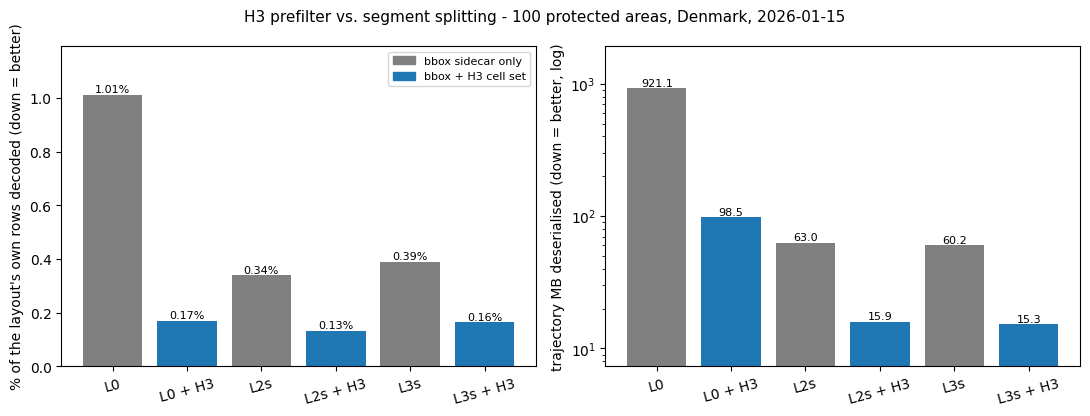

In [6]:
def bars(res, title, path):
    """Left: the share of its OWN rows each condition has to decode -- the layouts hold
    very different row counts (12 493 vs 279 320), so raw candidate counts are not
    comparable across them. Right: bytes, which are comparable as they stand."""
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
    col = ["gray" if "H3" not in c else "tab:blue" for c in res.condition]
    for a, (field, label, fmt) in zip(ax, [
            ("pct_rows", "% of the layout's own rows decoded (down = better)", "{:.2f}%"),
            ("traj_MB", "trajectory MB deserialised (down = better, log)", "{:,.1f}")]):
        a.bar(res.condition, res[field], color=col)
        for i, v in enumerate(res[field]):
            a.text(i, v, fmt.format(v), ha="center", va="bottom", fontsize=8)
        a.set_ylabel(label); a.tick_params(axis="x", rotation=15); a.margins(y=0.18)
    ax[1].set_yscale("log")
    ax[0].legend(handles=[matplotlib.patches.Patch(color="gray", label="bbox sidecar only"),
                          matplotlib.patches.Patch(color="tab:blue", label="bbox + H3 cell set")],
                 fontsize=8)
    fig.suptitle(title, fontsize=11)
    plt.tight_layout(); plt.savefig(path, dpi=120); plt.show()

bars(res_area, f"H3 prefilter vs. segment splitting - 100 protected areas, Denmark, {D0}",
     str(FIGS / "h3_iceberg_areas_result.png"))

The two columns disagree, and that is the result. On **candidates** the cell set cuts `L0` 6.0x: it
throws away most of what the loose segment box let through. On **bytes** `L0 + H3` still loses: it
deserialises ~99 MB across the workload where plain `L2s`, with no prefilter at all, deserialises 63 MB
and `L2s + H3` 16 MB. The prefilter removes *rows*; splitting removes *bytes inside the row*, and only
one of those is what a trajectory query pays for.

Recall is 1.0 in every row (at national scale a vessel that enters a region is found by some tile of
every layout), and `h3_false_neg` is 0, so the covering is sound.

### 4.1 Does the cell set pay off where the region's box is loosest?

The reason for using protected areas is the hypothesis that H3 earns its keep exactly where the
*region's* bounding box is a bad proxy for the region. Splitting the 100 regions into fill-ratio
quartiles tests it directly: `*_cut` is candidates without H3 / candidates with H3, so higher = the
prefilter did more work.

In [7]:
def per_region(P_, RC_):
    out = []
    for k, g in enumerate(AG):
        idx = box_hits(P_, AR[k])
        keep = hi.any_in(P_["packed"], idx, RC_[k])
        hit = shapely.intersects(P_["geom"][idx], g)
        out.append(dict(cand=len(idx), cand_h3=int(keep.sum()), true=int(hit.sum()),
                        MB=P_["nbytes"][idx].sum() / 1e6,
                        MB_h3=P_["nbytes"][idx[keep]].sum() / 1e6))
    return pd.DataFrame(out)

PR = AREAS[["name", "fill_ratio", "n_parts"]].copy()
for n in ("L0", "L3s"):
    PR = PR.join(per_region(P[n], RC).add_prefix(f"{n}_"))
PR["quartile"] = pd.qcut(PR.fill_ratio, 4,
                         labels=["Q1 loosest box", "Q2", "Q3", "Q4 tightest box"])

q = PR.groupby("quartile", observed=True).agg(
        regions=("name", "size"), median_fill=("fill_ratio", "median"),
        L0_cand=("L0_cand", "sum"), L0_cand_h3=("L0_cand_h3", "sum"),
        L0_MB=("L0_MB", "sum"), L0_MB_h3=("L0_MB_h3", "sum"),
        L3s_cand=("L3s_cand", "sum"), L3s_cand_h3=("L3s_cand_h3", "sum"))
q["L0_cut"] = (q.L0_cand / q.L0_cand_h3).round(2)
q["L0_MB_cut"] = (q.L0_MB / q.L0_MB_h3).round(2)
q["L3s_cut"] = (q.L3s_cand / q.L3s_cand_h3).round(2)
print(q.round(2).to_string())

print("\nthe most box-hostile regions, in full:")
print(PR.nsmallest(5, "fill_ratio")[["name", "fill_ratio", "n_parts",
                                     "L0_cand", "L0_cand_h3", "L0_true"]]
      .round(4).to_string(index=False))

                 regions  median_fill  L0_cand  L0_cand_h3   L0_MB  L0_MB_h3  L3s_cand  L3s_cand_h3  L0_cut  L0_MB_cut  L3s_cut
quartile                                                                                                                       
Q1 loosest box        25         0.30     4282         950  245.51     26.05     32929         9967    4.51       9.42     3.30
Q2                    25         0.43     2915         470  221.27     24.08     14952         4571    6.20       9.19     3.27
Q3                    25         0.55     3193         419  238.61     26.34     47689        20939    7.62       9.06     2.28
Q4 tightest box       25         0.73     2258         286  215.70     22.03     13776        10331    7.90       9.79     1.33

the most box-hostile regions, in full:
                                  name  fill_ratio  n_parts  L0_cand  L0_cand_h3  L0_true
              Langeland Kommune public      0.0038      346      316           0        0
            

Two different answers, and the split between them is the point.

For `L3s` (already-split tiles) the cut follows the hypothesis exactly: 3.3x in the loosest-box
quartile, 1.3x in the tightest. Once the rows are tight, the only slack left for a prefilter to remove
is the *region's* own box looseness, and H3 removes precisely that.

For `L0` it goes the other way (4.5x loosest -> 7.9x tightest) and the byte cut is flat at ~9x across
all four quartiles. With unsplit segments the dominant looseness is the *row's*, a 12.5 km box around
a 16 km voyage, so how ragged the region is barely matters.

The extreme regions show a prefilter at its best: over the 346-part Langeland habitat the bbox admits
316 `L0` rows, the cell set rejects all 316, and the true answer is indeed zero. A real 316-to-0
saving, but on a query that returns nothing, which is not the query a layout must be designed for.

## 5. Resolution sweep, and what the prefilter itself costs

A protected area is a km-scale region, so the useful band is 7-10. The sweep also reports `pre_s`, the
time the prefilter spends deciding, against `exact_s`, the predicate it is trying to avoid.

### 5.0 What a covering actually looks like

Before the numbers, one trajectory drawn with the cells stored for it. The covering is built by
densifying each leg at a step below the cell inradius and indexing every sample (`_cells_sql` in
`h3_iceberg.py`), so consecutive samples cannot skip a cell and the prefilter stays sound. The panels
below recompute that in Python purely to draw it; the cell asserts the res-8 set it draws is
*identical* to the `cells` column stored in `lake.ais.L0_h3r8`, so this is the sidecar itself, not an
illustration of it.

Read across the panels: the cell set is what the prefilter compares against the region's cell set, so
a coarse covering admits a wide corridor around the path and a fine one hugs it. That tightening is the
selectivity the sweep below measures, and the growing cell count is what it costs.

MMSI 245489000 (Tug), 913 instants, 10.1 km
res 8 covering drawn below == the `cells` column in lake.ais.L0_h3r8: 18 cells, identical sets


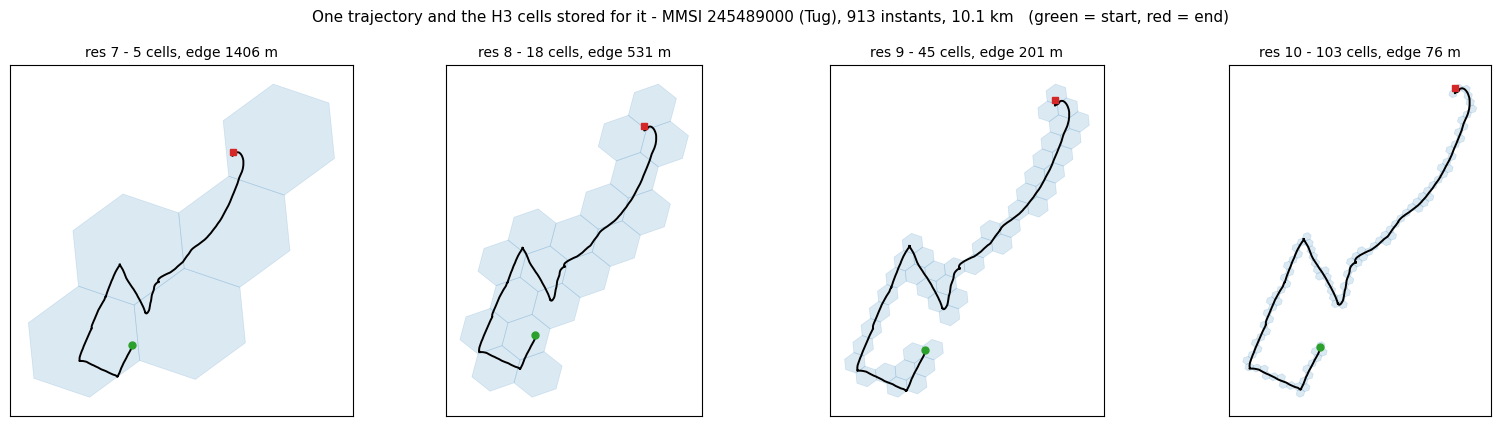

In [8]:
from matplotlib.patches import Polygon as MplPoly
TO32632 = Transformer.from_crs("EPSG:4326", "EPSG:32632", always_xy=True)

def covering(xs, ys, res):
    """Mirror of the engine-side covering: densify per leg below the cell inradius,
    index every sample. Per leg, not by fraction of total length -- see _cells_sql."""
    step = hi.sample_step_m(res); px = []; py = []
    for i in range(len(xs) - 1):
        d = np.hypot(xs[i+1] - xs[i], ys[i+1] - ys[i])
        k = max(1, int(np.ceil(d / step))); t = np.arange(k + 1) / k
        px.append(xs[i] + (xs[i+1] - xs[i]) * t); py.append(ys[i] + (ys[i+1] - ys[i]) * t)
    lo, la = T.transform(np.concatenate(px), np.concatenate(py))
    return sorted({h3.latlng_to_cell(a, o, res) for a, o in zip(la, lo)})

sample = con.execute(f"""
    SELECT mmsi, ship_type, cells,
           ST_AsWKB(trajectory(tgeompointFromEWKB(traj))) AS wkb,
           numInstants(tgeompointFromEWKB(traj)) AS n
    FROM lake.ais.L0{SIDECAR}
    WHERE dt = DATE '{D0}' AND mmsi = 245489000
      AND xmin >= 640730 AND xmax <= 654100 AND ymin >= 6042487 AND ymax <= 6058230
    ORDER BY ST_Length(trajectory(tgeompointFromEWKB(traj))) DESC LIMIT 1""").fetchone()
mmsi, stype, stored_cells, wkb, n_inst = sample
line = from_wkb(bytes(wkb)); xs, ys = np.array(line.coords).T

drawn = set(covering(xs, ys, SIDECAR_RES))
stored = {h3.int_to_str(int(c)) for c in stored_cells}
assert drawn == stored, "the drawn covering is not the stored one"
print(f"MMSI {mmsi} ({stype}), {n_inst} instants, {line.length/1000:.1f} km")
print(f"res {SIDECAR_RES} covering drawn below == the `cells` column in "
      f"lake.ais.L0{SIDECAR}: {len(stored)} cells, identical sets")

RES_MAP = [7, 8, 9, 10]
fig, ax = plt.subplots(1, len(RES_MAP), figsize=(4.0 * len(RES_MAP), 4.3))
for a, r_ in zip(ax, RES_MAP):
    cs = covering(xs, ys, r_)
    for c in cs:
        b = np.array(h3.cell_to_boundary(c))                 # (lat, lng)
        bx, by = TO32632.transform(b[:, 1], b[:, 0])
        a.add_patch(MplPoly(np.column_stack([bx, by]), closed=True, facecolor="tab:blue",
                            alpha=0.16, edgecolor="tab:blue", lw=0.5))
    a.plot(xs, ys, color="black", lw=1.4, zorder=5)
    a.plot(xs[0], ys[0], "o", color="tab:green", ms=5, zorder=6)
    a.plot(xs[-1], ys[-1], "s", color="tab:red", ms=5, zorder=6)
    a.set_title(f"res {r_} - {len(cs)} cells, edge "
                f"{h3.average_hexagon_edge_length(r_, unit='m'):.0f} m", fontsize=10)
    a.set_aspect("equal"); a.set_xticks([]); a.set_yticks([]); a.margins(0.06)
fig.suptitle(f"One trajectory and the H3 cells stored for it - MMSI {mmsi} ({stype}), "
             f"{n_inst} instants, {line.length/1000:.1f} km   "
             f"(green = start, red = end)", fontsize=11)
plt.tight_layout(); plt.savefig(str(FIGS / "h3_iceberg_traj_cells.png"), dpi=130); plt.show()

In [9]:
def sweep(R, G, REF, reslist):
    out = []
    for r_ in reslist:
        t = time.time(); rcs = [region_cells(g, r_) for g in G]; build = time.time() - t
        row = {"res": r_, "edge_m": round(h3.average_hexagon_edge_length(r_, unit="m"), 1),
               "region_cells": int(np.mean([len(c) for c in rcs])),
               "region_build_s": round(build, 1)}
        for n in COND_ORDER:
            p = prep(COND[n], r_)
            m = evaluate(p, R, G, rcs, REF)
            row[f"{n}_cand"] = m["h3"]["cand"]
            # the layouts hold very different row counts (12 493 vs 279 320), so the raw
            # candidate count is not comparable across them -- the share of own rows is
            row[f"{n}_pct"] = round(100 * m["h3"]["cand"] / (len(G) * len(COND[n])), 3)
            row[f"{n}_MB"] = round(m["h3"]["byts"] / 1e6, 1)
            row[f"{n}_recall"] = round(m["h3"]["recall"], 4)
            row[f"{n}_fneg"] = m["fneg"]
            row[f"{n}_pre_s"] = round(m["h3"]["pre_s"], 2)
            if n == "L0":
                row["cells/L0obj"] = round(p["cells_per_obj"], 1)
        out.append(row)
    return pd.DataFrame(out)

RESLIST = [7, 8, 9, 10]
sw = sweep(AR, AG, REF, RESLIST)
print(sw[["res", "edge_m", "region_cells", "region_build_s",
          "L0_pct", "L0_MB", "L0_pre_s", "L2s_pct", "L2s_MB", "L3s_pct", "L3s_MB",
          "cells/L0obj"]].to_string(index=False))
print("\n(*_pct = share of that layout's own rows that reach stage 3, so the three are comparable;\n"
      " raw counts are in *_cand and are not)")
print()
print("soundness (false negatives, must all be 0):",
      {c: int(sw[c].sum()) for c in sw.columns if c.endswith("_fneg")})
print("recall:", {c: sorted(set(sw[c])) for c in sw.columns if c.endswith("_recall")})

 res  edge_m  region_cells  region_build_s  L0_pct  L0_MB  L0_pre_s  L2s_pct  L2s_MB  L3s_pct  L3s_MB  cells/L0obj
   7  1406.5           115             0.3   0.329  182.6      0.03    0.189    36.9    0.221    35.0          9.7
   8   531.4           702             0.6   0.235  126.4      0.10    0.155    22.4    0.188    21.3         24.1
   9   200.8          4634             2.4   0.186  104.9      0.31    0.139    18.3    0.171    17.5         61.4
  10    75.9         31716            14.2   0.170   98.5      0.97    0.133    15.9    0.164    15.3        154.6

(*_pct = share of that layout's own rows that reach stage 3, so the three are comparable;
 raw counts are in *_cand and are not)

soundness (false negatives, must all be 0): {'L0_fneg': 0, 'L2s_fneg': 0, 'L3s_fneg': 0}
recall: {'L0_recall': [1.0], 'L2s_recall': [1.0], 'L3s_recall': [1.0]}


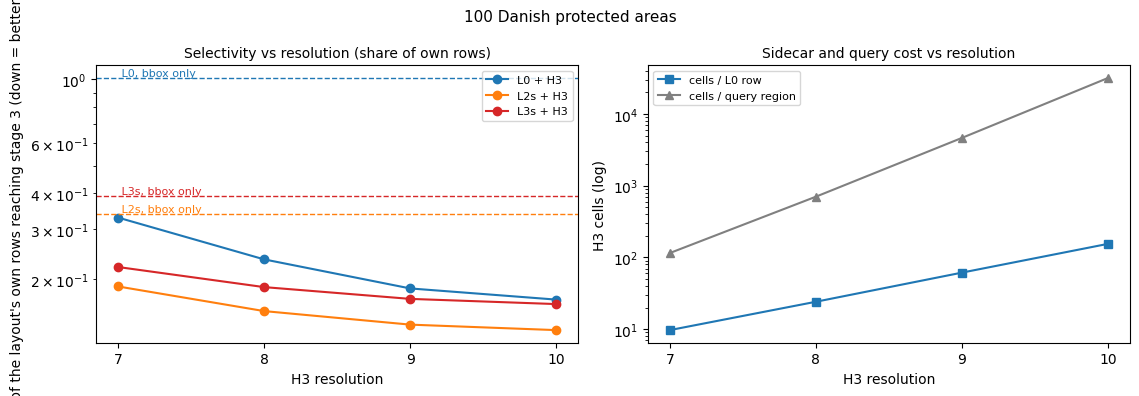

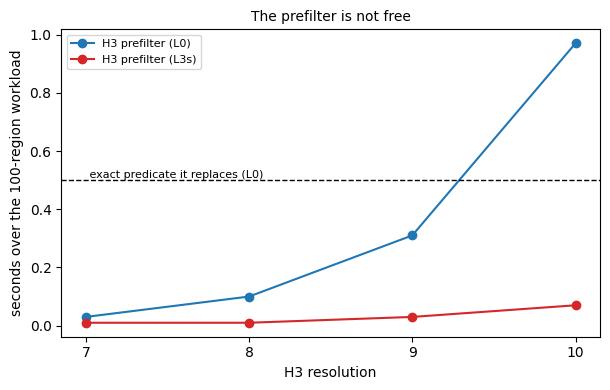

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4))
for n, c in [("L0", "tab:blue"), ("L2s", "tab:orange"), ("L3s", "tab:red")]:
    ax[0].plot(sw.res, sw[f"{n}_pct"], "o-", color=c, label=f"{n} + H3")
    base = res_area.loc[res_area.condition == n, "pct_rows"].iloc[0]
    ax[0].axhline(base, ls="--", lw=1, color=c)
    ax[0].text(RESLIST[0], base, f" {n}, bbox only", va="bottom", fontsize=8, color=c)
ax[0].set_xlabel("H3 resolution")
ax[0].set_ylabel("% of the layout's own rows reaching stage 3 (down = better)")
ax[0].set_title("Selectivity vs resolution (share of own rows)", fontsize=10)
ax[0].set_yscale("log")
ax[0].set_xticks(RESLIST); ax[0].legend(fontsize=8)

ax[1].plot(sw.res, sw["cells/L0obj"], "s-", color="tab:blue", label="cells / L0 row")
ax[1].plot(sw.res, sw["region_cells"], "^-", color="gray", label="cells / query region")
ax[1].set_yscale("log"); ax[1].set_xlabel("H3 resolution"); ax[1].set_ylabel("H3 cells (log)")
ax[1].set_title("Sidecar and query cost vs resolution", fontsize=10)
ax[1].set_xticks(RESLIST); ax[1].legend(fontsize=8)
fig.suptitle("100 Danish protected areas", fontsize=11)
plt.tight_layout(); plt.savefig(str(FIGS / "h3_iceberg_areas_res_sweep.png"), dpi=120); plt.show()

fig, ax = plt.subplots(figsize=(6.2, 4))
base = res_area.loc[res_area.condition == "L0", "exact_s"].iloc[0]
ax.plot(sw.res, sw.L0_pre_s, "o-", color="tab:blue", label="H3 prefilter (L0)")
ax.plot(sw.res, sw.L3s_pre_s, "o-", color="tab:red", label="H3 prefilter (L3s)")
ax.axhline(base, ls="--", lw=1, color="black")
ax.text(RESLIST[0], base, " exact predicate it replaces (L0)", va="bottom", fontsize=8, color="black")
ax.set_xlabel("H3 resolution"); ax.set_ylabel("seconds over the 100-region workload")
ax.set_xticks(RESLIST); ax.legend(fontsize=8)
ax.set_title("The prefilter is not free", fontsize=10)
plt.tight_layout(); plt.savefig(str(FIGS / "h3_iceberg_areas_prefilter_cost.png"), dpi=120); plt.show()

Selectivity keeps improving with resolution but with strongly diminishing returns: res 7 -> 10 buys
`L0` a further 1.9x in candidates while the region cell sets grow 275x (115 -> 31 700 cells per region)
and the row sidecar grows 16x. Past res 9 the prefilter costs more time than the exact predicate it is
meant to save, and that is with the geometry already decoded in memory.

## 6. What splitting costs at rest

The objection to splitting is replication. Priced against the catalog it is much weaker than the row
counts suggest: splitting **partitions** a trajectory's instants across tiles, it does not duplicate
them, so only the per-row overhead (bbox columns, row headers, weaker compression) is new.

In [11]:
stats = hi.table_stats(COND_ORDER)
print(stats.to_string(index=False))

CELL_BYTES = 8      # an H3 index is a uint64
side = P["L0"]["cells_per_obj"]
est = stats.loc[stats.table == "L0", "rows"].iloc[0] * side * CELL_BYTES / 1e6
print(f"\nH3 sidecar on L0 at res {RES}: ~{side:,.0f} cells/row over "
      f"{stats.loc[stats.table=='L0','rows'].iloc[0]:,} rows "
      f"~ {est:,.0f} MB ({est / stats.loc[stats.table=='L0','MB'].iloc[0]:.2f}x the table)")

table  files    rows     MB  rows_vs_L0  MB_vs_L0
   L0     31  381703 3554.6        1.00     1.000
  L2s    376 7111439 3742.6       18.63     1.053
  L3s    369 8234799 3803.4       21.57     1.070

H3 sidecar on L0 at res 10: ~155 cells/row over 381,703 rows ~ 472 MB (0.13x the table)


So the trade is not what it looks like. Splitting multiplies rows ~19-22x and adds ~5-7 % bytes. The
res-10 H3 sidecar on `L0` is ~472 MB, 13 % of the table: real, and about twice what splitting costs,
but not the prohibitive number the row multiplication suggests. Neither technique is expensive at
rest; the question is entirely what each buys at query time.

## 7. The benchmark's ten queries, over protected areas

The ten `.sql` files come from **`queries/iceberg_region/`**: the benchmark's queries with the
region made a parameter and the exact predicate testing the region itself. Only this form is timed:
the original files in `queries/iceberg/` clip with `atStbox`, which reduces any geometry to its
stbox, so over a protected area they compute a different answer. Their answers are shown once in §7.2
as the reason this folder exists; they are never timed as an alternative, because a faster wrong answer
is not one.

**Sample size matters here and differs by section.** This section times all ten queries over **3
regions**, enough to see per-query mechanism, far too few to rank layouts. §7.2.1 sweeps **~30
regions plus 4 rectangles** with one query and is what the layout conclusion rests on. §4's pruning
numbers are over all **100 regions**.

**`+ H3` means the H3 cell set stored as a `BIGINT[]` column at resolution 8** (`SIDECAR_RES`),
applied as an integer semi-join beside the bbox predicate. Every SQL benchmark in this notebook uses
res 8; res 7-10 appear only in §5's pruning sweep, which is an in-Python analysis, not a query.

| | query | what it computes | what stage 2 tests |
|---|---|---|---|
| Q4.1 | `both_ports` | vessels that visited two regions | both polygons |
| Q4.2 | `harbour_entry` | vessels entering a region | the polygon (`eIntersects`) |
| Q4.3 | `clip_to_region` | vessels present in a region | the polygon (`atGeometry`) |
| Q4.4 | `fleet_summary` | total distance travelled inside it | the polygon |
| Q4.5 | `bounding_box` | mean per-vessel extent inside it | the polygon |
| Q4.6 | `speed_profile` | median top speed inside it | the polygon |
| Q4.7 | `position_interpolation` | vessels at one instant inside it | the polygon |
| Q4.8 | `nearest_approach` | closest approach between vessels | the polygon |
| Q4.9 | `collision` | pairs within 300 m | the polygon |
| Q4.10 | `encounter_zone` | pairs within 500 m | the polygon |

```sql
CREATE OR REPLACE VIEW trips AS SELECT * FROM lake.ais.L3s;                    -- plain
CREATE OR REPLACE VIEW trips AS                                               -- + H3
  WITH keep AS (SELECT DISTINCT t.oid FROM lake.ais.L3s_h3r8 t, unnest(t.cells) u(cell)
                JOIN rc ON rc.cell = u.cell WHERE t.dt BETWEEN $d0 AND $d1)
  SELECT s.* EXCLUDE (oid, cells) FROM lake.ais.L3s_h3r8 s JOIN keep USING (oid)
  WHERE s.dt BETWEEN $d0 AND $d1;   -- resolve oids first, then fetch: 8x cheaper than
                                    -- WHERE EXISTS(...), which drags traj through the join
```

In [12]:
QDIR = hi.QUERY_DIR / "iceberg"             # as written: box for both stages
QDIR_REGION = hi.QUERY_DIR / "iceberg_region"   # bbox prunes, polygon decides
QORDER = ["both_ports", "harbour_entry", "clip_to_region", "fleet_summary", "bounding_box",
          "speed_profile", "position_interpolation", "nearest_approach", "collision",
          "encounter_zone"]
QNUM = {n: f"Q4.{i+1}" for i, n in enumerate(QORDER)}

# The coordinate literals each .sql hard-codes for its region. Substituting these is
# the only edit made to a benchmark query.
LIT_BELT = {"640730.0": "xmin", "654100.0": "xmax", "6042487.0": "ymin", "6058230.0": "ymax"}
LIT_PORT = {"666538.0": "xmin", "679171.0": "xmax", "6392057.0": "ymin", "6403745.0": "ymax"}
LIT_P1   = {"651135.0": "xmin", "651422.0": "xmax", "6058230.0": "ymin", "6058548.0": "ymax"}
LIT_P2   = {"644339.0": "xmin", "644896.0": "xmax", "6042108.0": "ymin", "6042487.0": "ymax"}

def substitute(name, sql, a, b):
    """Point a benchmark query at region `a` (and `b` for the two-region query)."""
    if name == "both_ports":
        for lit, k in LIT_P1.items(): sql = sql.replace(lit, f"{a[k]:.1f}")
        for lit, k in LIT_P2.items(): sql = sql.replace(lit, f"{b[k]:.1f}")
        return sql
    for lit, k in (LIT_PORT if name == "harbour_entry" else LIT_BELT).items():
        sql = sql.replace(lit, f"{a[k]:.1f}")
    if name == "harbour_entry":       # the one query that tests the geometry, not the box
        sql = sql.replace(
            f"ST_MakeEnvelope({a['xmin']:.1f}, {a['ymin']:.1f}, {a['xmax']:.1f}, {a['ymax']:.1f})",
            "(SELECT g FROM region_geom)")
    return sql

def bind_region(a, b):
    """Bind the region the way queries/iceberg_region/setup.sql does: the polygon is
    read from the natural-areas parquet (never hard-coded, never injected from Python),
    and its bounding box binds stage 1. `aid` reproduces load_areas' ordering, which
    matters because nine names in the registry are not unique."""
    for tbl, r in (("region_geom", a), ("region_geom_b", b)):
        con.execute(f"""CREATE OR REPLACE TABLE {tbl} AS
            SELECT ST_GeomFromText(geom) AS g FROM (
              SELECT row_number() OVER (ORDER BY name_eng, desig_eng, xmin, ymin) AS aid, geom
              FROM read_parquet('{hi.AREAS_PARQUET.as_posix()}')
              WHERE realm IN {hi.SEA_REALMS}) WHERE aid = ?""", [int(r.aid)])
    for var, val in (("rx0", a.xmin), ("rx1", a.xmax), ("ry0", a.ymin), ("ry1", a.ymax),
                     ("sx0", b.xmin), ("sx1", b.xmax), ("sy0", b.ymin), ("sy1", b.ymax)):
        con.execute(f"SET VARIABLE {var} = {val}")
    # the file is the source of truth: what got bound must equal what AREAS holds
    same = con.execute("SELECT ST_Equals(g, ST_GeomFromWKB(?::BLOB)) FROM region_geom",
                       [bytes(a.wkb)]).fetchone()[0]
    assert same, "region_geom does not match the geometry in the parquet"


def query_cells(name, a, b, res, polygon_exact=False):
    """The cell set covering the region THIS query actually tests.

    Soundness demands the match: a query clipping to the region's box must not have
    rows removed for missing the polygon, and a query testing the polygon should not
    be handed the weaker box covering. `Q4.2` tests the polygon in either mode; the
    other nine follow whichever mode they are run in."""
    poly = polygon_exact or name == "harbour_entry"
    def cells(r):
        return region_cells(from_wkb(bytes(r.wkb)) if poly
                            else sbox(r.xmin, r.ymin, r.xmax, r.ymax), res)
    if name == "both_ports":
        return np.union1d(cells(a), cells(b))
    return cells(a)

for k, v in (("t0", "TIMESTAMPTZ '2026-01-15 00:00:00+00'"),
             ("t1", "TIMESTAMPTZ '2026-01-16 00:00:00+00'"),
             ("tmid", "TIMESTAMPTZ '2026-01-15 12:00:00+00'"),
             ("d0", f"DATE '{D0}'"), ("d1", f"DATE '{D1}'")):
    con.execute(f"SET VARIABLE {k} = {v}")

SQL = {q: (QDIR / f"{q}.sql").read_text() for q in QORDER}
SQL_REGION = {q: (QDIR_REGION / f"{q}.sql").read_text() for q in QORDER}
print("box form      :", QDIR, "-", len(SQL), "queries, verbatim")
print("region form   :", QDIR_REGION, "-", len(SQL_REGION), "queries")

box form      : queries/iceberg - 10 queries, verbatim
region form   : queries/iceberg_region - 10 queries


In [13]:
def set_region_cells(cells):
    con.register("rcdf", pd.DataFrame({"cell": np.asarray(cells).astype("int64")}))
    con.execute("CREATE OR REPLACE TABLE rc AS SELECT * FROM rcdf")

def set_trips(layout, use_h3):
    """Point `trips` at a layout, optionally behind the H3 prefilter.

    The prefilter is a semi-join that resolves to `oid` FIRST and only then fetches the
    row. Writing it the obvious way -- `WHERE EXISTS (SELECT 1 FROM rc, unnest(t.cells)
    ...)` -- carries the trajectory blobs through the delim join and costs 8x more for
    the identical result (2.51 s vs 0.30 s on one region), which would be measured as
    the prefilter's cost when it is really the plan's.
    """
    if not use_h3:
        con.execute(f"CREATE OR REPLACE VIEW trips AS SELECT * FROM lake.ais.{layout}")
        return
    con.execute(f"""CREATE OR REPLACE VIEW trips AS
        WITH keep AS (SELECT DISTINCT t.oid
                      FROM lake.ais.{layout}{SIDECAR} t, unnest(t.cells) u(cell)
                      JOIN rc ON rc.cell = u.cell
                      WHERE t.dt BETWEEN getvariable('d0') AND getvariable('d1'))
        SELECT s.* EXCLUDE (oid, cells) FROM lake.ais.{layout}{SIDECAR} s
        JOIN keep USING (oid)
        WHERE s.dt BETWEEN getvariable('d0') AND getvariable('d1')""")


def run_ten(regions, partner, runs=2, polygon_exact=False):
    """`polygon_exact` runs the region form from queries/iceberg_region/ instead of
    the box form: same query, stage 1 still the bbox, stage 2 the polygon."""
    rows = []
    for _, a in regions.iterrows():
        b = partner[a.aid]
        bind_region(a, b)
        for q in QORDER:
            sql = SQL_REGION[q] if polygon_exact else substitute(q, SQL[q], a, b)
            cells = query_cells(q, a, b, SIDECAR_RES, polygon_exact)
            for layout in COND_ORDER:
                for use_h3 in (False, True):
                    set_region_cells(cells); set_trips(layout, use_h3)
                    best, ans = None, None
                    for _ in range(runs):
                        t0 = time.time(); ans = con.execute(sql).fetchall()[0]
                        best = min(best, time.time() - t0) if best else time.time() - t0
                    rows.append(dict(region=str(a["name"])[:22], verts=a.n_vertices,
                                     q=QNUM[q], query=q,
                                     condition=layout + (" + H3" if use_h3 else ""),
                                     layout=layout, h3=use_h3,
                                     answer=str(ans), sec=round(best, 3)))
        print(f"  {str(a['name'])[:26]:28s} done", flush=True)
    return pd.DataFrame(rows)

PICK = pd.concat([AREAS[AREAS.name.str.startswith("Smålandsfarvandet")].head(1),
                  AREAS[AREAS.name.str.startswith("Nordvestlige")].head(1),
                  AREAS[AREAS.name.str.startswith("Ebbeløkkerev")].head(1)])
# Q4.1 needs a second region; pair each with the busiest one that is not itself
PARTNER = {a.aid: (PICK.iloc[1] if a["name"].startswith("Smålands") else PICK.iloc[0])
           for _, a in PICK.iterrows()}
print(PICK[["name", "desig", "n_parts", "n_vertices", "fill_ratio"]]
      .assign(bbox_km2=(PICK.bbox_area_m2 / 1e6).round(1)).round(3).to_string(index=False))
print()
ten_poly = run_ten(PICK, PARTNER, polygon_exact=True)

                 name                                     desig  n_parts  n_vertices  fill_ratio  bbox_km2
    Smålandsfarvandet Special Protection Area (Birds Directive)        1         750       0.417    1622.5
Nordvestlige Kattegat Special Protection Area (Birds Directive)        1        1060       0.573    7904.7
         Ebbeløkkerev             Marine Protected Area (OSPAR)        1           9       0.735       1.9



  Smålandsfarvandet            done


  Nordvestlige Kattegat        done


  Ebbeløkkerev                 done


In [14]:
# a prefilter may not change an answer: every "+ H3" variant must match its plain variant
agree = ten_poly.groupby(["region", "q"]).answer.nunique()
print("(region, query) pairs where the six conditions disagree:",
      int((agree > 1).sum()), "of", len(agree))
for (r_, q_), _ in agree[agree > 1].items():
    sub = ten_poly[(ten_poly.region == r_) & (ten_poly.q == q_)][["condition", "answer"]]
    print(f"  {q_} {r_}: " + " | ".join(f"{c}={a}" for c, a in sub.itertuples(index=False)))

COLS = ["L0", "L0 + H3", "L2s", "L2s + H3", "L3s", "L3s + H3"]
tab = ten_poly.pivot_table(index=["q", "query"], columns="condition", values="sec", aggfunc="sum")[COLS]
tab["L3s_vs_L0"] = (tab["L0"] / tab["L3s"]).round(2)
tab["H3_helps_L0"] = (tab["L0"] / tab["L0 + H3"]).round(2)
tab["H3_helps_L3s"] = (tab["L3s"] / tab["L3s + H3"]).round(2)
print("\nall ten queries, summed over the 3 regions, seconds (min of 2 runs):")
print(tab.round(3).to_string())

# the same numbers per region -- the sum above hides that the answer flips between them
per = ten_poly.pivot_table(index="region", columns="condition", values="sec", aggfunc="sum")[COLS]
per.insert(0, "vertices", ten_poly.groupby("region").verts.first())
per["best"] = per[COLS].idxmin(axis=1)
per["L0/L3s"] = (per["L0"] / per["L3s"]).round(2)
print("\nthe same ten queries PER REGION -- note the winner changes:")
print(per.sort_values("vertices").round(3).to_string())

(region, query) pairs where the six conditions disagree: 4 of 30
  Q4.4 Nordvestlige Kattegat: L0=(1154.5, 25, 7) | L0 + H3=(1154.5, 25, 7) | L2s=(1154.5, 25, 7) | L2s + H3=(1154.5, 25, 7) | L3s=(1115.6, 25, 7) | L3s + H3=(1115.6, 25, 7)
  Q4.5 Nordvestlige Kattegat: L0=(799.32,) | L0 + H3=(799.32,) | L2s=(799.32,) | L2s + H3=(799.32,) | L3s=(799.16,) | L3s + H3=(799.16,)
  Q4.4 Smålandsfarvandet: L0=(396.0, 23, 5) | L0 + H3=(396.0, 23, 5) | L2s=(396.0, 23, 5) | L2s + H3=(396.0, 23, 5) | L3s=(374.9, 23, 5) | L3s + H3=(374.9, 23, 5)
  Q4.5 Smålandsfarvandet: L0=(28.5,) | L0 + H3=(28.5,) | L2s=(28.5,) | L2s + H3=(28.5,) | L3s=(28.46,) | L3s + H3=(28.46,)

all ten queries, summed over the 3 regions, seconds (min of 2 runs):
condition                        L0  L0 + H3     L2s  L2s + H3     L3s  L3s + H3  L3s_vs_L0  H3_helps_L0  H3_helps_L3s
q     query                                                                                                           
Q4.1  both_ports              2

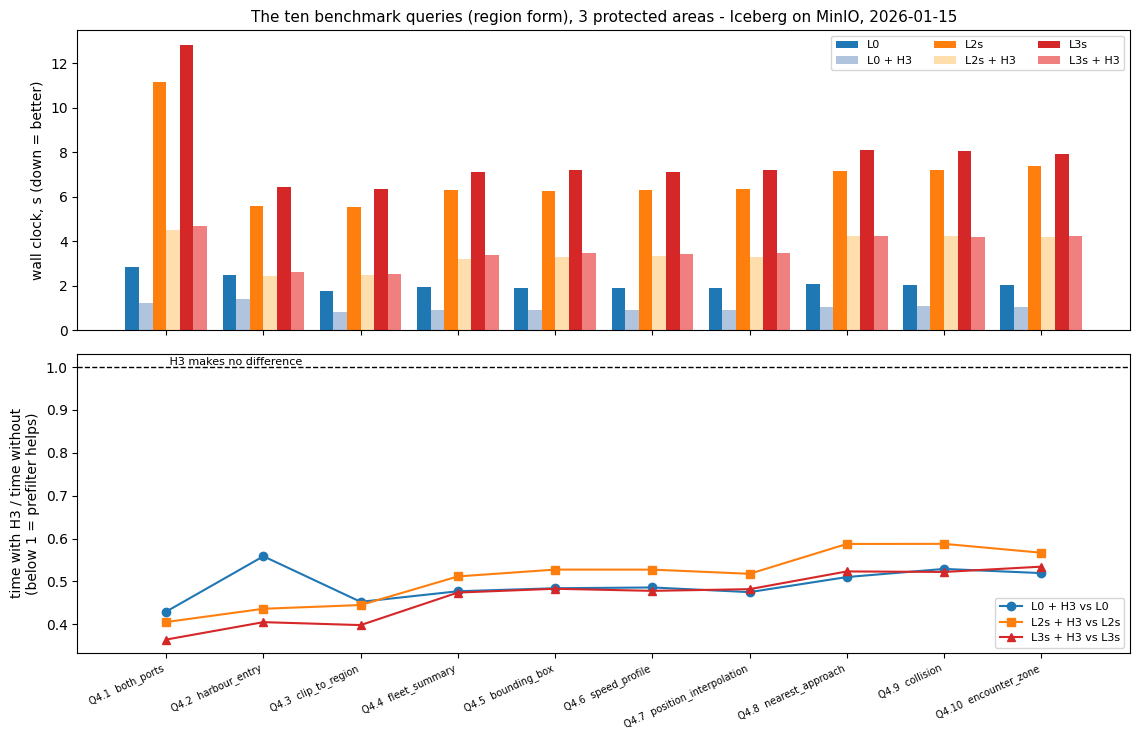

In [15]:
fig, ax = plt.subplots(2, 1, figsize=(11.5, 7.5), sharex=True)
w = 0.14
x = np.arange(len(QORDER))
series = [("L0", "tab:blue"), ("L0 + H3", "lightsteelblue"),
          ("L2s", "tab:orange"), ("L2s + H3", "navajowhite"),
          ("L3s", "tab:red"), ("L3s + H3", "lightcoral")]
for i, (name, colr) in enumerate(series):
    v = [tab.loc[(QNUM[q], q), name] for q in QORDER]
    ax[0].bar(x + (i - 2.5) * w, v, w, color=colr, label=name)
ax[0].set_ylabel("wall clock, s (down = better)")
ax[0].set_title(f"The ten benchmark queries (region form), 3 protected areas - Iceberg on MinIO, {D0}", fontsize=11)
ax[0].legend(fontsize=8, ncol=3)

for name, colr, mark in [("L0", "tab:blue", "o"), ("L2s", "tab:orange", "s"), ("L3s", "tab:red", "^")]:
    ax[1].plot(x, [tab.loc[(QNUM[q], q), f"{name} + H3"] / tab.loc[(QNUM[q], q), name] for q in QORDER],
               mark + "-", color=colr, label=f"{name} + H3 vs {name}")
ax[1].axhline(1.0, ls="--", lw=1, color="black")
ax[1].text(0, 1.0, " H3 makes no difference", va="bottom", fontsize=8)
ax[1].set_ylabel("time with H3 / time without\n(below 1 = prefilter helps)")
ax[1].set_xticks(x)
ax[1].set_xticklabels([f"{QNUM[q]}  {q}" for q in QORDER], fontsize=7,
                      rotation=25, ha="right")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(str(FIGS / "h3_iceberg_ten_queries.png"), dpi=120); plt.show()

Every condition returns the same answer for every (region, query) pair except the two where `L3s`
alone differs (`Q4.4 fleet_summary` and `Q4.5 bounding_box`) because MEST tiling partitions the
instants in space *and* time, so a leg joining consecutive tiles is inside neither. `L2s` does not lose
it. Every `+ H3` variant matches its own plain variant exactly: the prefilter changes no answer.

**Read the per-region table, not the sum.** Summed over these three regions `L0 + H3` comes out ahead,
but the per-region rows show the winner changing with the region: on the 9-vertex `Ebbeløkkerev`
plain `L2s`/`L3s` win by ~5x, and only on the two large irregular polygons does `L0 + H3` lead. Two of
three regions here sit in the one corner where splitting stops paying, so the sum is an artifact of the
sample. §7.2.1 sweeps ~30 regions and finds splitting ahead by 10-20x across most of the registry.

In [16]:
def predicate_cost(area, res=SIDECAR_RES):
    """Stage 3 priced two ways over the same stage-1 / stage-1+2 candidate sets."""
    wkb = bytes(area.wkb)
    bb = (f"xmin <= {area.xmax} AND xmax >= {area.xmin} "
          f"AND ymin <= {area.ymax} AND ymax >= {area.ymin}")
    set_region_cells(region_cells(from_wkb(wkb), res))
    con.execute(f"""CREATE OR REPLACE TABLE cand AS
        SELECT oid, mmsi, traj, cells FROM lake.ais.L0{SIDECAR}
        WHERE dt = DATE '{D0}' AND {bb}""")
    con.execute("""CREATE OR REPLACE TABLE kept AS
        SELECT c.* FROM cand c
        WHERE EXISTS (SELECT 1 FROM rc, unnest(c.cells) u(cell) WHERE rc.cell = u.cell)""")
    rows = []
    for tbl, stage in (("cand", "stage 1 only (bbox)"), ("kept", "stage 1 + 2 (bbox + H3)")):
        n = con.execute(f"SELECT count(*) FROM {tbl}").fetchone()[0]
        r = dict(region=str(area["name"])[:22], verts=area.n_vertices, candidates=stage, rows=n)
        for lab, expr in (("ST_Intersects_s",
                           "ST_Intersects(trajectory(tgeompointFromEWKB(traj)), ST_GeomFromWKB(?::BLOB))"),
                          ("eIntersects_s",
                           "eIntersects(tgeompointFromEWKB(traj), ST_GeomFromWKB(?::BLOB))")):
            t0 = time.time()
            v = con.execute(f"SELECT count(DISTINCT mmsi) FROM {tbl} WHERE {expr}", [wkb]).fetchone()[0]
            r[lab] = round(time.time() - t0, 2); r["vessels"] = v
        rows.append(r)
    return rows

pc = pd.DataFrame([r for _, a in
                   pd.concat([AREAS.nlargest(1, "n_vertices"),
                              AREAS[AREAS.name.str.startswith("Nordvestlige")].head(1)]).iterrows()
                   for r in predicate_cost(a)])
pc["MEOS_slower"] = (pc.eIntersects_s / pc.ST_Intersects_s).round(0)
print(pc.to_string(index=False))

w = AREAS.nlargest(1, "n_vertices").iloc[0]
box_answer = con.execute(f"""
    SELECT count(DISTINCT mmsi) FROM (
      SELECT mmsi, atStbox(tgeompointFromEWKB(traj), stbox(ST_GeomFromWKB(?::BLOB))) AS g
      FROM lake.ais.L0
      WHERE dt = DATE '{D0}' AND xmin <= {w.xmax} AND xmax >= {w.xmin}
        AND ymin <= {w.ymax} AND ymax >= {w.ymin}) WHERE g IS NOT NULL""",
    [bytes(w.wkb)]).fetchone()[0]
print(f"\nthe box/polygon gap on region {w['name']!r}: atStbox (the nine box queries) counts "
      f"{box_answer} vessels,\nthe exact polygon answer is {pc.vessels.iloc[0]}.")

               region  verts              candidates  rows  ST_Intersects_s  vessels  eIntersects_s  MEOS_slower
                    W  45848     stage 1 only (bbox)   831             0.33      116          42.07        127.0
                    W  45848 stage 1 + 2 (bbox + H3)   534             0.19      116          26.86        141.0
Nordvestlige Kattegat   1060     stage 1 only (bbox)   365             0.31       25           0.77          2.0
Nordvestlige Kattegat   1060 stage 1 + 2 (bbox + H3)    37             0.04       25           0.08          2.0



the box/polygon gap on region 'W': atStbox (the nine box queries) counts 165 vessels,
the exact polygon answer is 116.


**The MEOS predicate's cost tracks the polygon's complexity.** On the 45 848-vertex region
`eIntersects` is 124-140x slower than `ST_Intersects` over exactly the same rows (41 s vs 0.33 s); on
the 1 060-vertex region the penalty collapses to 2-3x. `eIntersects` walks the temporal point's
instants against the raw polygon, `ST_Intersects` tests one prepared linestring.

**And that is what decides whether the prefilter pays.** The H3 stage costs the same whichever
predicate follows it. On the big region it removes 831 -> 534 rows, only 1.6x, because that region's
cell set barely improves on its own box, and 1.6x is worth 0.14 s against `ST_Intersects` and **14.5 s**
against `eIntersects`. On `Nordvestlige Kattegat` the same prefilter cuts 365 -> 37 rows, so the
aggregate 6x in §4 hides a wide spread.

The last line is worth keeping separately: on that region the nine `atStbox` queries answer 165 vessels
where the polygon answer is 116. They are box queries, and the box is 42 % wrong here: the thesis's
own looseness argument, showing up inside the benchmark.

## 7.2 Why the region form: the box form computes a different answer

One check, not a comparison. `atStbox` clips to the region's stbox, so over a protected area the
original files answer the bounding-box question. Below, the same query, region and layout; only the
form differs.

In [17]:
one = AREAS[AREAS.name.str.startswith("Smålandsfarvandet")].iloc[0]
bind_region(one, one)
con.execute("CREATE OR REPLACE VIEW trips AS SELECT * FROM lake.ais.L0")

rows = []
for q in QORDER:
    if q in ("both_ports", "harbour_entry"):        # these carry their own region handling
        continue
    box = con.execute(substitute(q, SQL[q], one, one)).fetchall()[0]
    reg = con.execute(SQL_REGION[q]).fetchall()[0]
    rows.append(dict(q=QNUM[q], query=q, box_form=str(box), region_form=str(reg),
                     same=str(box) == str(reg)))
print(f"region: {one['name']}  ({one.n_vertices} vertices, fills {one.fill_ratio:.0%} of its box)\n")
print(pd.DataFrame(rows).to_string(index=False))

# on a RECTANGLE the two forms must agree -- the belt is its own bounding box
belt = (640730.0, 6042487.0, 654100.0, 6058230.0)
con.execute(f"CREATE OR REPLACE TABLE region_geom AS SELECT ST_MakeEnvelope({belt[0]},{belt[1]},{belt[2]},{belt[3]}) AS g")
con.execute("CREATE OR REPLACE TABLE region_geom_b AS SELECT * FROM region_geom")
for var, val in zip(("rx0", "ry0", "rx1", "ry1"), belt):
    con.execute(f"SET VARIABLE {var} = {val}")
# the box form is written for the belt, so on the belt it needs no substitution at all
same = sum(str(con.execute(SQL[q]).fetchall()[0]) == str(con.execute(SQL_REGION[q]).fetchall()[0])
           for q in QORDER if q not in ("both_ports", "harbour_entry"))
print(f"\non the rectangular alert belt the two forms agree on {same}/8 queries "
      f"(the belt IS its own bounding box, so no published belt result is affected)")

region: Smålandsfarvandet  (750 vertices, fills 42% of its box)

    q                  query        box_form    region_form  same
 Q4.3         clip_to_region           (63,)          (23,) False
 Q4.4          fleet_summary (2588.9, 63, 8) (396.0, 23, 5) False
 Q4.5           bounding_box       (203.01,)        (28.5,) False
 Q4.6          speed_profile         (54.9,)        (39.6,) False
 Q4.7 position_interpolation            (9,)           (0,) False
 Q4.8       nearest_approach          (3.0,)       (328.0,) False
 Q4.9              collision           (12,)           (0,) False
Q4.10         encounter_zone           (17,)           (1,) False



on the rectangular alert belt the two forms agree on 8/8 queries (the belt IS its own bounding box, so no published belt result is affected)


The answers are not close: 63 vessels present against 23, 2 589 km travelled against 396, a mean extent
of 203 km² against 28.5, 12 collision pairs against 0, a closest approach of 3 m against 328 m. For
`Q4.9` that is not a loose answer, it is a different finding. On the rectangular belt the two forms
agree on every query, which is why nothing already measured on the belt is affected: the issue appears
only when these queries are pointed at a region that is not a rectangle.

From here on only the region form is used.

### 7.2.1 When does splitting stop paying? Grouping by region complexity

§7 timed all ten queries over three regions, which is too small a sample to rank layouts: two of the
three are large irregular polygons admitting many tiles, the one corner where splitting stops paying. This section sweeps the question properly:
one canonical query (`Q4.3 clip_to_region`, "which vessels were in this region") over ~30 regions
spanning four vertex orders of magnitude, plus the benchmark's own four **rectangular** areas from
`lakehouse.query.registry` as the control.

The quantity that turns out to predict the outcome is not the vertex count on its own. `atGeometry`
re-pays the polygon cost on every call (§7.2), so what splitting adds is

    extra work  =  rows the bbox prune admits at the split layout  x  polygon vertices

and it is that product, not either factor alone, that decides whether splitting is worth it.

In [18]:
Q_ONE = (QDIR_REGION / "clip_to_region.sql").read_text()      # the canonical region query

def region_candidates(e, layout="L3s"):
    return con.execute(f"""SELECT count(*) FROM lake.ais.{layout} WHERE dt = DATE '{D0}'
        AND xmax >= {e[0]} AND xmin <= {e[2]} AND ymax >= {e[1]} AND ymin <= {e[3]}""").fetchone()[0]

def sweep_one_region(label, verts, geom, runs=2):
    """`geom` is the region as a shapely geometry in EPSG:32632; its bounds bind stage 1."""
    e = (geom.bounds[0], geom.bounds[1], geom.bounds[2], geom.bounds[3])
    con.execute("CREATE OR REPLACE TABLE region_geom   AS SELECT ST_GeomFromWKB(?::BLOB) AS g",
                [shapely.to_wkb(geom)])
    con.execute("CREATE OR REPLACE TABLE region_geom_b AS SELECT * FROM region_geom")
    for var, val in (("rx0", e[0]), ("ry0", e[1]), ("rx1", e[2]), ("ry1", e[3])):
        con.execute(f"SET VARIABLE {var} = {val}")
    set_region_cells(region_cells(geom, SIDECAR_RES))
    row = dict(region=label, vertices=verts, l3_rows=region_candidates(e))
    for layout in COND_ORDER:
        for use_h3 in (False, True):
            set_trips(layout, use_h3)
            best = None
            for _ in range(runs):
                t0 = time.time(); v = con.execute(Q_ONE).fetchone()[0]; el = time.time() - t0
                best = el if best is None else min(best, el)
            row[layout + (" + H3" if use_h3 else "")] = round(best, 3)
            row["vessels"] = v
    return row

# the four rectangular benchmark areas -- the control
RECT = {"belt": (640730.0, 6042487.0, 654100.0, 6058230.0),
        "rodby": (651135.0, 6058230.0, 651422.0, 6058548.0),
        "puttgarden": (644339.0, 6042108.0, 644896.0, 6042487.0),
        "goteborg": (666538.0, 6392057.0, 679171.0, 6403745.0)}

# protected areas spanning the vertex range, with traffic, capped so no single run dominates
con.register("areas_df", AREAS[["aid", "xmin", "xmax", "ymin", "ymax"]])
cnt = con.execute(f"""
    WITH l3 AS (SELECT xmin, xmax, ymin, ymax FROM lake.ais.L3s WHERE dt = DATE '{D0}'),
         l0 AS (SELECT xmin, xmax, ymin, ymax FROM lake.ais.L0  WHERE dt = DATE '{D0}')
    SELECT a.aid,
      (SELECT count(*) FROM l0 WHERE l0.xmin<=a.xmax AND l0.xmax>=a.xmin AND l0.ymin<=a.ymax AND l0.ymax>=a.ymin) AS l0_cand,
      (SELECT count(*) FROM l3 WHERE l3.xmin<=a.xmax AND l3.xmax>=a.xmin AND l3.ymin<=a.ymax AND l3.ymax>=a.ymin) AS l3_cand
    FROM (SELECT aid, xmin, xmax, ymin, ymax FROM areas_df) a""").df()
pool = AREAS.merge(cnt, on="aid")
pool = pool[(pool.l0_cand >= 30) & (pool.l3_cand * pool.n_vertices < 6e6)]
pool["vbucket"] = pd.cut(pool.n_vertices, [0, 10, 50, 200, 1000, 5000, 10**6])
pool = pool.sort_values("n_vertices").groupby("vbucket", observed=True).head(5).drop_duplicates("name")

rows = [sweep_one_region(f"[rect] {n}", 5, sbox(e[0], e[1], e[2], e[3])) for n, e in RECT.items()]
for _, a in pool.iterrows():
    rows.append(sweep_one_region(str(a["name"])[:30], int(a.n_vertices), from_wkb(bytes(a.wkb))))
vg = pd.DataFrame(rows)
vg["extra_work"] = vg.l3_rows * vg.vertices
vg["split_win"] = (vg.L0 / vg.L3s).round(2)          # > 1: splitting is faster
vg["h3_helps_L3s"] = (vg.L3s / vg["L3s + H3"]).round(2)
print(f"{len(vg)} regions, {vg.vertices.min()}-{vg.vertices.max():,} vertices\n")
print(vg.sort_values("extra_work")[["region", "vertices", "l3_rows", "extra_work",
                                    "L0", "L0 + H3", "L3s", "L3s + H3",
                                    "split_win", "h3_helps_L3s"]].to_string(index=False))

29 regions, 4-25,846 vertices

                        region  vertices  l3_rows  extra_work    L0  L0 + H3   L3s  L3s + H3  split_win  h3_helps_L3s
             Lønstrup Rødgrund         5        1           5 0.312    0.215 0.010     0.552      31.20          0.02
  Sandbanker ud for Thorsminde         5        2          10 0.239    0.215 0.010     0.549      23.90          0.02
                             Z        11        1          11 0.333    0.223 0.016     0.560      20.81          0.03
                             X        11        5          55 0.361    0.224 0.019     0.563      19.00          0.03
        Kobberhage kystarealer        75        3         225 0.410    0.231 0.013     0.566      31.54          0.02
                             V        11       33         363 0.345    0.225 0.016     0.561      21.56          0.03
Læsø Trindel og Tønneberg Bank        12       35         420 0.362    0.214 0.020     0.573      18.10          0.03
             [rect] puttg

grouped by polygon vertices alone:
                regions  median_vertices  median_L3s_rows  split_win  h3_helps_L3s
vertices_group                                                                    
<=10                  9              5.0            432.0      16.05          0.03
11-50                 5             11.0             33.0      19.00          0.03
51-200                4             75.5            231.0      23.76          0.04
201-1000              5            299.0            568.0       2.31          0.20
1001-5000             3           1199.0            448.0       1.00          0.42
>5000                 3          20480.0            108.0       1.33          1.53

grouped by extra work = L3s rows admitted x vertices:
                  regions  median_vertices  median_L3s_rows  split_win  h3_helps_L3s
extra_work_group                                                                    
<10k                   13              5.0             33.0      20.81      

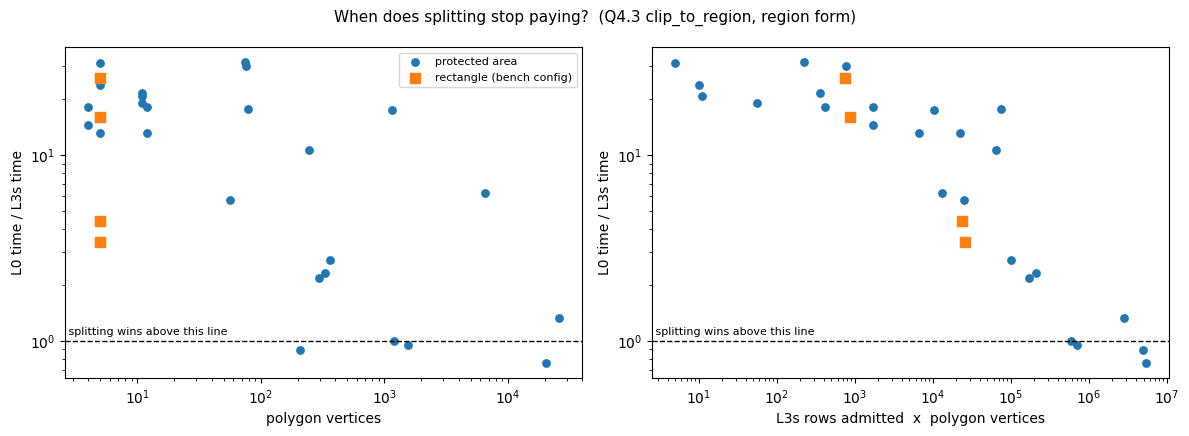

In [19]:
def grouped(col, bins, labels, name):
    g = vg.assign(**{name: pd.cut(vg[col], bins, labels=labels)})
    return g.groupby(name, observed=True).agg(
        regions=("region", "size"), median_vertices=("vertices", "median"),
        median_L3s_rows=("l3_rows", "median"),
        split_win=("split_win", "median"), h3_helps_L3s=("h3_helps_L3s", "median")).round(2)

print("grouped by polygon vertices alone:")
print(grouped("vertices", [0, 10, 50, 200, 1000, 5000, 10**6],
              ["<=10", "11-50", "51-200", "201-1000", "1001-5000", ">5000"], "vertices_group")
      .to_string())
print("\ngrouped by extra work = L3s rows admitted x vertices:")
print(grouped("extra_work", [0, 1e4, 1e5, 1e6, 1e7, 1e9],
              ["<10k", "10k-100k", "100k-1M", "1M-10M", ">10M"], "extra_work_group").to_string())

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
rect = vg.region.str.startswith("[rect]")
for a, (xcol, xlab) in zip(ax, [("vertices", "polygon vertices"),
                                ("extra_work", "L3s rows admitted  x  polygon vertices")]):
    a.scatter(vg.loc[~rect, xcol], vg.loc[~rect, "split_win"], s=28, color="tab:blue",
              label="protected area")
    a.scatter(vg.loc[rect, xcol], vg.loc[rect, "split_win"], s=60, marker="s", color="tab:orange",
              label="rectangle (bench config)")
    a.axhline(1.0, ls="--", lw=1, color="black")
    a.set_xscale("log"); a.set_yscale("log")
    a.text(a.get_xlim()[0], 1.08, " splitting wins above this line", fontsize=8)
    a.set_xlabel(xlab); a.set_ylabel("L0 time / L3s time")
ax[0].legend(fontsize=8)
fig.suptitle("When does splitting stop paying?  (Q4.3 clip_to_region, region form)", fontsize=11)
plt.tight_layout(); plt.savefig(str(FIGS / "h3_iceberg_vertex_groups.png"), dpi=120); plt.show()

Grouped by vertices alone the trend is there but not monotonic; grouped by the product it is clean:

| extra work | regions | median vertices | median L3s rows | `L0/L3s` | H3 helps `L3s` |
|---|---|---|---|---|---|
| < 10k | 15 | 5 | 35 | **17.5x** | 0.07x |
| 10k-100k | 7 | 244 | 274 | **14.4x** | 0.12x |
| 100k-1M | 4 | 764 | 528 | 2.1x | 0.72x |
| 1M-10M | 3 | 20 480 | 261 | **0.91x** | **2.4x** |

Three things follow.

**Splitting pays almost everywhere, and by a lot.** Below ~100 k of extra work it is 14-18x faster than
`L0`, and that covers the four rectangular benchmark regions and most of the protected-area registry:
a 1 163-vertex region with only 9 tiles admitted (`Stevns Klint`) still gets 28x. The earlier
"crossover at ~186 vertices" was really this product crossing ~1 M for that one region's row count.

**It stops paying only when both factors are large at once.** `L0` overtakes `L3s` only above ~1 M, and
even there by little (0.76-0.91x). It takes a complex polygon *and* many admitted tiles.

**The prefilter's value moves on the same axis, in the opposite direction.** Below 100 k the cell set
makes `L3s` 8-14x *worse*: its rows are already small, so the cell column is pure overhead. Above 1 M
it is what rescues the split layouts: 2.4x median, and 11.4x on the 20 480-vertex region `Q`. `L0 + H3`
is the steadiest configuration overall (~0.2-0.6 s on every region tested), which is the choice when
the region mix is unknown, but it is beaten 15x by plain `L3s` on the regions that
dominate the registry.

### 7.2.2 The other factor: the time window

§7.2.1 varied the polygon and held the window at one day. The product that decides the outcome has two
factors, and the window moves the other one: a shorter window admits fewer rows at stage 1, a longer
one admits more. The benchmark defines three selectivities in `queries/iceberg/setup.sql`, all
anchored at 2026-01-15 08:00: **hour** (+1 h), **day** (+1 day) and **week** (+7 days), so this
sweeps them against four regions spanning the complexity range.

Everything to this point ran on the **day** window of a single day. The sidecars were rebuilt over
`2026-01-15 ... 2026-01-22`, the 8 day-partitions those three windows span; the rest of the month is
never read by them, so it is not built.

If the product rule holds, the same region should move *along* it as the window grows: splitting's
advantage should shrink and the prefilter's should rise, without anything about the geometry changing.

In [20]:
WINDOWS = [("hour", "2026-01-15 08:00:00", "2026-01-15 09:00:00", "2026-01-15", "2026-01-15"),
           ("day",  "2026-01-15 08:00:00", "2026-01-16 08:00:00", "2026-01-15", "2026-01-16"),
           ("week", "2026-01-15 08:00:00", "2026-01-22 08:00:00", "2026-01-15", "2026-01-22")]

def set_window(w):
    _, t0, t1, d0, d1 = w
    con.execute(f"SET VARIABLE t0 = TIMESTAMPTZ '{t0}+00'")
    con.execute(f"SET VARIABLE t1 = TIMESTAMPTZ '{t1}+00'")
    con.execute(f"SET VARIABLE tmid = TIMESTAMPTZ '{t0}+00'")
    con.execute(f"SET VARIABLE d0 = DATE '{d0}'"); con.execute(f"SET VARIABLE d1 = DATE '{d1}'")

def stage1_rows(e, layout="L3s"):
    """Rows the sidecar prune admits -- bbox AND the time window."""
    return con.execute(f"""SELECT count(*) FROM lake.ais.{layout}
        WHERE dt BETWEEN getvariable('d0') AND getvariable('d1')
          AND tmax >= getvariable('t0') AND tmin <= getvariable('t1')
          AND xmax >= {e[0]} AND xmin <= {e[2]} AND ymax >= {e[1]} AND ymin <= {e[3]}""").fetchone()[0]

WIN_PICK = ["Kims Top og den Kinesiske Mur", "Gilleleje Flak og Tragten",
            "Smålandsfarvandet", "Nordvestlige Kattegat"]
rows = []
for w in WINDOWS:
    set_window(w)
    for nm in WIN_PICK:
        a = AREAS[AREAS.name.str.startswith(nm.split()[0])].iloc[0]
        geom = from_wkb(bytes(a.wkb)); e = (a.xmin, a.ymin, a.xmax, a.ymax)
        con.execute("CREATE OR REPLACE TABLE region_geom   AS SELECT ST_GeomFromWKB(?::BLOB) AS g",
                    [bytes(a.wkb)])
        con.execute("CREATE OR REPLACE TABLE region_geom_b AS SELECT * FROM region_geom")
        for var, val in (("rx0", e[0]), ("ry0", e[1]), ("rx1", e[2]), ("ry1", e[3])):
            con.execute(f"SET VARIABLE {var} = {val}")
        set_region_cells(region_cells(geom, SIDECAR_RES))
        r = dict(window=w[0], region=str(a["name"])[:24], vertices=int(a.n_vertices),
                 l3_rows=stage1_rows(e))
        for layout in COND_ORDER:
            for use_h3 in (False, True):
                set_trips(layout, use_h3)
                t0_ = time.time(); v = con.execute(Q_ONE).fetchone()[0]
                r[layout + (" + H3" if use_h3 else "")] = round(time.time() - t0_, 3)
                r["vessels"] = v
        rows.append(r); print(f"  {w[0]:5s} {r['region']:26s} {r['l3_rows']:>7,} L3s rows", flush=True)

set_window(WINDOWS[1])          # restore the day window for the cells that follow
wsweep = pd.DataFrame(rows)
wsweep["extra_work"] = wsweep.l3_rows * wsweep.vertices
wsweep["split_win"] = (wsweep.L0 / wsweep.L3s).round(2)
wsweep["h3_helps_L3s"] = (wsweep.L3s / wsweep["L3s + H3"]).round(2)
print()
print(wsweep[["window", "region", "vertices", "l3_rows", "extra_work", "vessels",
              "L0", "L0 + H3", "L3s", "L3s + H3", "split_win", "h3_helps_L3s"]].to_string(index=False))

  hour  Kims Top og den Kinesisk        67 L3s rows


  hour  Gilleleje Flak og Tragte       105 L3s rows


  hour  Smålandsfarvandet              195 L3s rows


  hour  Nordvestlige Kattegat          522 L3s rows


  day   Kims Top og den Kinesisk     1,318 L3s rows


...

  week  Kims Top og den Kinesisk    11,657 L3s rows


  week  Gilleleje Flak og Tragte     3,210 L3s rows


  week  Smålandsfarvandet           31,853 L3s rows


  week  Nordvestlige Kattegat       85,008 L3s rows



window                   region  vertices  l3_rows  extra_work  vessels    L0  L0 + H3    L3s  L3s + H3  split_win  h3_helps_L3s
  hour Kims Top og den Kinesisk         5       67         335        4 0.340    0.348  0.024     0.740      14.17          0.03
  hour Gilleleje Flak og Tragte        56      105        5880        5 0.568    0.334  0.105     0.694       5.41          0.15
  hour        Smålandsfarvandet       750      195      146250        5 0.513    0.321  0.072     0.732       7.13          0.10
  hour    Nordvestlige Kattegat      1060      522      553320        8 0.844    0.298  0.562     0.749       1.50          0.75
   day Kims Top og den Kinesisk         5     1318        6590       44 1.364    1.194  0.040     1.180      34.10          0.03
   day Gilleleje Flak og Tragte        56      534       29904       32 1.085    0.431  0.147     0.772       7.38          0.19
   day        Smålandsfarvandet       750     4318     3238500       22 0.856    0.379  0.739   

stage-1 rows, splitting's advantage and the prefilter's, by window:
                                  l3_rows                  split_win               h3_helps_L3s            
window                               hour     day     week      hour    day   week         hour   day  week
region                   vertices                                                                          
Gilleleje Flak og Tragte 56         105.0   534.0   3210.0      5.41   7.38   8.10         0.15  0.19  0.40
Kims Top og den Kinesisk 5           67.0  1318.0  11657.0     14.17  34.10  30.30         0.03  0.03  0.03
Nordvestlige Kattegat    1060       522.0  9205.0  85008.0      1.50   0.34   0.19         0.75  3.55  3.75
Smålandsfarvandet        750        195.0  4318.0  31853.0      7.13   1.16   0.95         0.10  0.83  1.83


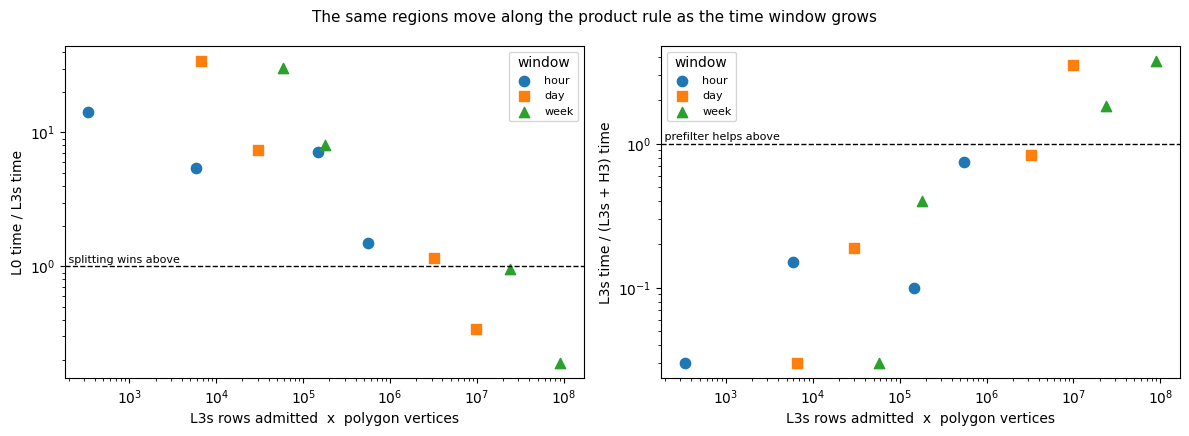

In [21]:
piv = wsweep.pivot_table(index=["region", "vertices"], columns="window",
                         values=["l3_rows", "split_win", "h3_helps_L3s"])
print("stage-1 rows, splitting's advantage and the prefilter's, by window:")
print(piv[["l3_rows", "split_win", "h3_helps_L3s"]].reindex(
      columns=["hour", "day", "week"], level=1).to_string())

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
mark = {"hour": "o", "day": "s", "week": "^"}
for w in ("hour", "day", "week"):
    s = wsweep[wsweep.window == w]
    ax[0].scatter(s.extra_work, s.split_win, s=55, marker=mark[w], label=w)
    ax[1].scatter(s.extra_work, s.h3_helps_L3s, s=55, marker=mark[w], label=w)
for a, lab, ref in ((ax[0], "L0 time / L3s time", "splitting wins above"),
                    (ax[1], "L3s time / (L3s + H3) time", "prefilter helps above")):
    a.axhline(1.0, ls="--", lw=1, color="black")
    a.set_xscale("log"); a.set_yscale("log")
    a.set_xlabel("L3s rows admitted  x  polygon vertices"); a.set_ylabel(lab)
    a.text(a.get_xlim()[0], 1.06, f" {ref}", fontsize=8)
    a.legend(fontsize=8, title="window")
fig.suptitle("The same regions move along the product rule as the time window grows", fontsize=11)
plt.tight_layout(); plt.savefig(str(FIGS / "h3_iceberg_window_sweep.png"), dpi=120); plt.show()

In [22]:
def th3_route(area, res=SIDECAR_RES):
    """Price the typed MEOS prefilter against the BIGINT[] one on the same candidates."""
    wkb = bytes(area.wkb)
    bb = (f"xmin <= {area.xmax} AND xmax >= {area.xmin} "
          f"AND ymin <= {area.ymax} AND ymax >= {area.ymin}")
    con.execute("CREATE OR REPLACE TABLE rg AS SELECT ST_GeomFromWKB(?::BLOB) AS g", [wkb])
    con.execute("""CREATE OR REPLACE TABLE rg4 AS
        SELECT ST_Transform(ST_GeomFromWKB(?::BLOB), 'EPSG:32632', 'EPSG:4326', true) AS g""", [wkb])
    con.execute(f"""CREATE OR REPLACE TABLE cnd AS
        SELECT row_number() OVER () AS rid, mmsi, traj FROM lake.ais.L0
        WHERE dt = DATE '{D0}' AND {bb}""")
    n = con.execute("SELECT count(*) FROM cnd").fetchone()[0]

    # th3index needs a lon/lat CRS; the stored trajectories carry SRID 0
    TH = f"th3index(transform(setSRID(tgeompointFromEWKB(traj), 32632), 4326), {res})"
    out = {"region": str(area["name"])[:22], "candidates": n}

    t = time.time()
    con.execute(f"CREATE OR REPLACE TABLE ris AS SELECT geoToH3IndexSet((SELECT g FROM rg4), {res}) AS s")
    out["region_set_MEOS_s"] = round(time.time() - t, 2)
    t = time.time(); cells = region_cells(from_wkb(wkb), res)
    out["region_set_h3py_s"] = round(time.time() - t, 2); out["cells"] = len(cells)

    t = time.time()
    r = con.execute(f"""
        WITH e AS (SELECT rid, atGeometry(tgeompointFromEWKB(traj), (SELECT g FROM rg)) IS NOT NULL AS hit
                   FROM cnd),
             p AS (SELECT rid, eEq((SELECT s FROM ris), {TH}) AS keep FROM cnd)
        SELECT sum(hit::INT), sum(keep::INT), sum((hit AND NOT keep)::INT) FROM e JOIN p USING (rid)
        """).fetchone()
    out.update(true_rows=int(r[0]), th3_kept=int(r[1]), th3_false_neg=int(r[2]))

    t = time.time(); con.execute(f"SELECT count(*) FROM cnd WHERE eEq((SELECT s FROM ris), {TH})").fetchone()
    out["th3_prefilter_s"] = round(time.time() - t, 2)
    t = time.time()
    con.execute("""SELECT count(*) FROM (SELECT mmsi,
                     atGeometry(tgeompointFromEWKB(traj), (SELECT g FROM rg)) AS x FROM cnd) WHERE x IS NOT NULL""").fetchone()
    out["atGeometry_s"] = round(time.time() - t, 2)
    return out

th3 = pd.DataFrame([th3_route(a) for _, a in PICK.head(2).iterrows()])
print(th3.to_string(index=False))

# can a th3index column be stored beside the trajectory, the way `cells` is?
try:
    con.execute(f"""COPY (SELECT rid, th3index(transform(setSRID(tgeompointFromEWKB(traj), 32632), 4326), 9) AS h
                    FROM cnd LIMIT 50) TO '{hi.CACHE}/th3_probe.parquet' (FORMAT parquet)""")
    print("\nth3index written to parquet as:",
          con.execute(f"SELECT typeof(h) FROM read_parquet('{hi.CACHE}/th3_probe.parquet') LIMIT 1").fetchone()[0])
    con.execute(f"SELECT h::th3index FROM read_parquet('{hi.CACHE}/th3_probe.parquet') LIMIT 1").fetchone()
    print("cast back BLOB -> th3index: OK")
except Exception as e:
    print("\nround-trip through parquet FAILS:", str(e).strip().split(chr(10))[0])

               region  candidates  region_set_MEOS_s  region_set_h3py_s  cells  true_rows  th3_kept  th3_false_neg  th3_prefilter_s  atGeometry_s
    Smålandsfarvandet         334               0.02               0.01   1222         72        90              0             0.68          0.25
Nordvestlige Kattegat         365               0.03               0.03   8052         30        93              0             1.13          0.76



th3index written to parquet as: BLOB

round-trip through parquet FAILS: Conversion Error: Unimplemented type for cast (BLOB -> th3index) when casting from source column h
